In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")
print("Pandas version:", pd.__version__)

Libraries loaded successfully!
Pandas version: 2.2.3


In [2]:
from pathlib import Path

# Location of our Olist dataset
DATA_DIR = Path("../olist")

# Load the orders dataset
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")

print("Orders shape:", orders.shape)
print("\nColumns:")
print(orders.columns.tolist())

Orders shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [3]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [4]:
# Keep only delivered orders
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# Check missing values in the delivery-related columns
print("Delivered orders:", len(delivered_orders))
print("\nMissing values:")
print(
    delivered_orders[
        [
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ].isna().sum()
)

Delivered orders: 96478

Missing values:
order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64


In [5]:
# Remove delivered orders where the actual delivery date is missing
delivered_orders = delivered_orders.dropna(
    subset=["order_delivered_customer_date"]
).copy()

# Convert date columns to datetime
delivered_orders["order_delivered_customer_date"] = pd.to_datetime(
    delivered_orders["order_delivered_customer_date"]
)

delivered_orders["order_estimated_delivery_date"] = pd.to_datetime(
    delivered_orders["order_estimated_delivery_date"]
)

# Create the target variable
delivered_orders["late_delivery"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
).astype(int)

print("Orders available for ML:", len(delivered_orders))
print("\nLate delivery distribution:")
print(delivered_orders["late_delivery"].value_counts())

print("\nLate delivery percentage:")
print(delivered_orders["late_delivery"].mean() * 100)

Orders available for ML: 96470

Late delivery distribution:
late_delivery
0    88644
1     7826
Name: count, dtype: int64

Late delivery percentage:
8.112366538820359


In [6]:
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")

print("Order items shape:", order_items.shape)
print("\nColumns:")
print(order_items.columns.tolist())

print("\nFirst 5 rows:")
display(order_items.head())

Order items shape: (112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 5 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
# Create order-level features from the order items table

order_item_features = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_item_price=("price", "mean")
    )
    .reset_index()
)

print("Order-level feature shape:", order_item_features.shape)

print("\nFeatures created:")
print(order_item_features.columns.tolist())

print("\nFirst 5 rows:")
display(order_item_features.head())

Order-level feature shape: (98666, 5)

Features created:
['order_id', 'item_count', 'total_price', 'total_freight', 'avg_item_price']

First 5 rows:


,order_id,item_count,total_price,total_freight,avg_item_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,199.90


In [8]:
# Load the payment dataset
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")

print("Payments shape:", payments.shape)

print("\nColumns:")
print(payments.columns.tolist())

print("\nFirst 5 rows:")
display(payments.head())

Payments shape: (103886, 5)

Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

First 5 rows:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
# Create order-level payment features

payment_features = (
    payments
    .groupby("order_id")
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

print("Payment feature shape:", payment_features.shape)

print("\nFeatures created:")
print(payment_features.columns.tolist())

print("\nPayment type distribution:")
print(payment_features["payment_type"].value_counts())

print("\nFirst 5 rows:")
display(payment_features.head())

Payment feature shape: (99440, 4)

Features created:
['order_id', 'payment_value_total', 'payment_installments_max', 'payment_type']

Payment type distribution:
payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
not_defined        3
Name: count, dtype: int64

First 5 rows:


,order_id,payment_value_total,payment_installments_max,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [10]:
# Load customer data
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")

print("Customers shape:", customers.shape)

print("\nColumns:")
print(customers.columns.tolist())

print("\nFirst 5 rows:")
display(customers.head())

Customers shape: (99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

First 5 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
# Load seller data
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")

print("Sellers shape:", sellers.shape)

print("\nColumns:")
print(sellers.columns.tolist())

print("\nFirst 5 rows:")
display(sellers.head())

Sellers shape: (3095, 4)

Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

First 5 rows:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [12]:
# Add customer state to our delivered orders

delivered_orders = delivered_orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

print("Shape after adding customer information:", delivered_orders.shape)

print("\nCustomer state missing values:")
print(delivered_orders["customer_state"].isna().sum())

Shape after adding customer information: (96470, 10)

Customer state missing values:
0


In [13]:
# Create order-level seller features
# An order may contain products from multiple sellers

seller_features = (
    order_items
    .groupby("order_id")
    .agg(
        seller_count=("seller_id", "nunique"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

print("Seller feature shape:", seller_features.shape)
print("\nFeatures created:")
print(seller_features.columns.tolist())

print("\nFirst 5 rows:")
display(seller_features.head())

Seller feature shape: (98666, 3)

Features created:
['order_id', 'seller_count', 'seller_id']

First 5 rows:


,order_id,seller_count,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,1,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87


In [14]:
# Add seller state to our order-level seller features

seller_features = seller_features.merge(
    sellers[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

print("Seller features after adding state:", seller_features.shape)

print("\nMissing seller states:")
print(seller_features["seller_state"].isna().sum())

print("\nSeller state distribution:")
print(seller_features["seller_state"].value_counts().head(10))

Seller features after adding state: (98666, 4)

Missing seller states:
0

Seller state distribution:
seller_state
SP    69968
MG     7844
PR     7590
RJ     4311
SC     3615
RS     1976
DF      819
BA      568
GO      463
PE      406
Name: count, dtype: int64


In [15]:
# Add seller information to our delivered orders

delivered_orders = delivered_orders.merge(
    seller_features[["order_id", "seller_count", "seller_state"]],
    on="order_id",
    how="left"
)

print("Shape after adding seller information:", delivered_orders.shape)

print("\nMissing seller information:")
print(
    delivered_orders[
        ["seller_count", "seller_state"]
    ].isna().sum()
)

Shape after adding seller information: (96470, 12)

Missing seller information:
seller_count    0
seller_state    0
dtype: int64


In [16]:
# Add order-item features

delivered_orders = delivered_orders.merge(
    order_item_features,
    on="order_id",
    how="left"
)

print("Shape after adding order-item features:", delivered_orders.shape)

print("\nMissing order-item features:")
print(
    delivered_orders[
        [
            "item_count",
            "total_price",
            "total_freight",
            "avg_item_price"
        ]
    ].isna().sum()
)

print("\nFirst 5 rows:")
display(
    delivered_orders[
        [
            "order_id",
            "item_count",
            "total_price",
            "total_freight",
            "avg_item_price"
        ]
    ].head()
)

Shape after adding order-item features: (96470, 16)

Missing order-item features:
item_count        0
total_price       0
total_freight     0
avg_item_price    0
dtype: int64

First 5 rows:


,order_id,item_count,total_price,total_freight,avg_item_price
0,e481f51cbdc54678b7cc49136f2d6af7,1,29.99,8.72,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,1,118.70,22.76,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,1,159.90,19.22,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,1,45.00,27.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,1,19.90,8.72,19.90


In [17]:
# Add payment features

delivered_orders = delivered_orders.merge(
    payment_features,
    on="order_id",
    how="left"
)

print("Shape after adding payment features:", delivered_orders.shape)

print("\nMissing payment features:")
print(
    delivered_orders[
        [
            "payment_value_total",
            "payment_installments_max",
            "payment_type"
        ]
    ].isna().sum()
)

print("\nPayment type distribution:")
print(delivered_orders["payment_type"].value_counts())

Shape after adding payment features: (96470, 19)

Missing payment features:
payment_value_total         1
payment_installments_max    1
payment_type                1
dtype: int64

Payment type distribution:
payment_type
credit_card    73213
boleto         19191
voucher         2582
debit_card      1483
Name: count, dtype: int64


In [18]:
# Remove the single order with missing payment information

before = len(delivered_orders)

delivered_orders = delivered_orders.dropna(
    subset=[
        "payment_value_total",
        "payment_installments_max",
        "payment_type"
    ]
).copy()

after = len(delivered_orders)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

print("\nRemaining missing payment values:")
print(
    delivered_orders[
        [
            "payment_value_total",
            "payment_installments_max",
            "payment_type"
        ]
    ].isna().sum()
)

Rows before: 96470
Rows after: 96469
Rows removed: 1

Remaining missing payment values:
payment_value_total         0
payment_installments_max    0
payment_type                0
dtype: int64


In [19]:
# Convert purchase timestamp to datetime

delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"]
)

# Create time-based features
delivered_orders["purchase_year"] = (
    delivered_orders["order_purchase_timestamp"].dt.year
)

delivered_orders["purchase_month"] = (
    delivered_orders["order_purchase_timestamp"].dt.month
)

delivered_orders["purchase_dayofweek"] = (
    delivered_orders["order_purchase_timestamp"].dt.dayofweek
)

delivered_orders["purchase_hour"] = (
    delivered_orders["order_purchase_timestamp"].dt.hour
)

delivered_orders["purchase_weekend"] = (
    delivered_orders["purchase_dayofweek"] >= 5
).astype(int)

print("Time-based features created.")

print("\nNew features:")
print([
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_weekend"
])

print("\nSample:")
display(
    delivered_orders[
        [
            "order_purchase_timestamp",
            "purchase_year",
            "purchase_month",
            "purchase_dayofweek",
            "purchase_hour",
            "purchase_weekend",
            "late_delivery"
        ]
    ].head()
)

Time-based features created.

New features:
['purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_weekend']

Sample:


,order_purchase_timestamp,purchase_year,purchase_month,purchase_dayofweek,purchase_hour,purchase_weekend,late_delivery
0,2017-10-02 10:56:33,2017,10,0,10,0,0
1,2018-07-24 20:41:37,2018,7,1,20,0,0
2,2018-08-08 08:38:49,2018,8,2,8,0,0
3,2017-11-18 19:28:06,2017,11,5,19,1,0
4,2018-02-13 21:18:39,2018,2,1,21,0,0


In [20]:
# Check the complete ML dataset

print("Final dataset shape:", delivered_orders.shape)

print("\nAll columns:")
print(delivered_orders.columns.tolist())

print("\nMissing values:")
print(
    delivered_orders.isna().sum().sort_values(ascending=False)
)

print("\nTarget distribution:")
print(delivered_orders["late_delivery"].value_counts())

print("\nTarget percentage:")
print(
    delivered_orders["late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final dataset shape: (96469, 24)

All columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'late_delivery', 'customer_state', 'seller_count', 'seller_state', 'item_count', 'total_price', 'total_freight', 'avg_item_price', 'payment_value_total', 'payment_installments_max', 'payment_type', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_weekend']

Missing values:
order_approved_at                14
order_delivered_carrier_date      1
order_id                          0
total_price                       0
purchase_hour                     0
purchase_dayofweek                0
purchase_month                    0
purchase_year                     0
payment_type                      0
payment_installments_max          0
payment_value_total               0
avg_item_price                    0
total_freight        

In [21]:
# Select features for the ML model

feature_columns = [
    # Order characteristics
    "item_count",
    "total_price",
    "total_freight",
    "avg_item_price",

    # Payment information
    "payment_value_total",
    "payment_installments_max",
    "payment_type",

    # Customer / seller location
    "customer_state",
    "seller_state",
    "seller_count",

    # Purchase timing
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_weekend"
]

X = delivered_orders[feature_columns].copy()
y = delivered_orders["late_delivery"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (96469, 15)
Target shape: (96469,)

Features used:
['item_count', 'total_price', 'total_freight', 'avg_item_price', 'payment_value_total', 'payment_installments_max', 'payment_type', 'customer_state', 'seller_state', 'seller_count', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_weekend']

Target distribution:
late_delivery
0    88644
1     7825
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (77175, 15)
Test set: (19294, 15)

Training target distribution:
late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64

Test target distribution:
late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Separate numerical and categorical features

numeric_features = [
    "item_count",
    "total_price",
    "total_freight",
    "avg_item_price",
    "payment_value_total",
    "payment_installments_max",
    "seller_count",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_weekend"
]

categorical_features = [
    "payment_type",
    "customer_state",
    "seller_state"
]

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")
print("\nNumerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessing pipeline created successfully!

Numerical features: 12
Categorical features: 3


In [24]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Probability of late delivery
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Basic metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["On-time", "Late"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6463
ROC-AUC: 0.647

Classification Report:
              precision    recall  f1-score   support

     On-time       0.94      0.66      0.77     17729
        Late       0.12      0.55      0.20      1565

    accuracy                           0.65     19294
   macro avg       0.53      0.60      0.49     19294
weighted avg       0.88      0.65      0.73     19294


Confusion Matrix:
[[11616  6113]
 [  712   853]]


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [27]:
# Make predictions
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["On-time", "Late"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9054
Random Forest ROC-AUC: 0.7356

Classification Report:
              precision    recall  f1-score   support

     On-time       0.93      0.97      0.95     17729
        Late       0.33      0.16      0.22      1565

    accuracy                           0.91     19294
   macro avg       0.63      0.57      0.58     19294
weighted avg       0.88      0.91      0.89     19294


Confusion Matrix:
[[17211   518]
 [ 1308   257]]


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    predictions = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(3))

   Threshold  Precision  Recall     F1
0       0.20      0.182   0.597  0.278
1       0.25      0.212   0.507  0.298
2       0.30      0.238   0.419  0.304
3       0.35      0.257   0.338  0.292
4       0.40      0.283   0.276  0.280
5       0.45      0.308   0.217  0.255
6       0.50      0.328   0.165  0.220


In [29]:
# Final threshold for business risk flagging
best_threshold = 0.30

rf_pred_threshold = (rf_prob >= best_threshold).astype(int)

print("Threshold:", best_threshold)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred_threshold,
        target_names=["On-time", "Late"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred_threshold))

Threshold: 0.3

Classification Report:
              precision    recall  f1-score   support

     On-time       0.95      0.88      0.91     17729
        Late       0.24      0.42      0.30      1565

    accuracy                           0.84     19294
   macro avg       0.59      0.65      0.61     19294
weighted avg       0.89      0.84      0.86     19294


Confusion Matrix:
[[15634  2095]
 [  909   656]]


In [31]:
# Get the trained Random Forest model
rf_model = random_forest_model.named_steps["model"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importance_values = rf_model.feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(20))

                          Feature  Importance
8             num__purchase_month    0.130660
2              num__total_freight    0.122597
4        num__payment_value_total    0.115565
3             num__avg_item_price    0.108455
1                num__total_price    0.107688
10             num__purchase_hour    0.096578
9         num__purchase_dayofweek    0.058135
5   num__payment_installments_max    0.050750
7              num__purchase_year    0.022510
41         cat__customer_state_SP    0.015599
34         cat__customer_state_RJ    0.012923
11          num__purchase_weekend    0.010577
64           cat__seller_state_SP    0.010279
13  cat__payment_type_credit_card    0.009996
0                 num__item_count    0.009763
12       cat__payment_type_boleto    0.009388
26         cat__customer_state_MG    0.008556
50           cat__seller_state_MG    0.005816
58           cat__seller_state_RJ    0.005717
57           cat__seller_state_PR    0.005628


In [32]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_result = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create dataframe
permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values(
    by="Importance_Mean",
    ascending=False
)

print(permutation_importance_df)

                     Feature  Importance_Mean  Importance_Std
11            purchase_month         0.152990        0.004626
7             customer_state         0.067152        0.003090
10             purchase_year         0.064377        0.005841
8               seller_state         0.023695        0.002688
2              total_freight         0.019606        0.001877
6               payment_type         0.002499        0.000940
9               seller_count         0.001896        0.000490
0                 item_count         0.001739        0.000189
3             avg_item_price         0.001515        0.003004
13             purchase_hour         0.001208        0.001211
5   payment_installments_max         0.001109        0.001129
1                total_price        -0.001538        0.003105
14          purchase_weekend        -0.002763        0.001022
12        purchase_dayofweek        -0.003171        0.001718
4        payment_value_total        -0.005568        0.002930


In [33]:
# Create prediction dataframe for the test set

prediction_df = delivered_orders.loc[
    X_test.index,
    [
        "order_id",
        "customer_state",
        "seller_state",
        "total_price",
        "total_freight",
        "item_count",
        "late_delivery"
    ]
].copy()

# Add model predictions
prediction_df["late_probability"] = rf_prob
prediction_df["predicted_late"] = rf_pred_threshold

# Create business-friendly risk categories
prediction_df["risk_category"] = pd.cut(
    prediction_df["late_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Save predictions
prediction_df.to_csv("ml_predictions.csv", index=False)

print("Prediction file created successfully!")
print("Shape:", prediction_df.shape)
print("\nColumns:")
print(prediction_df.columns.tolist())
print("\nRisk distribution:")
print(prediction_df["risk_category"].value_counts())

Prediction file created successfully!
Shape: (19294, 10)

Columns:
['order_id', 'customer_state', 'seller_state', 'total_price', 'total_freight', 'item_count', 'late_delivery', 'late_probability', 'predicted_late', 'risk_category']

Risk distribution:
risk_category
Low Risk       16592
Medium Risk     2350
High Risk        352
Name: count, dtype: int64


In [34]:
# Load customer reviews
reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv"
)

print("Reviews shape:", reviews.shape)

print("\nColumns:")
print(reviews.columns.tolist())

print("\nMissing review scores:")
print(reviews["review_score"].isna().sum())

Reviews shape: (99224, 7)

Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Missing review scores:
0


In [35]:
# Check whether any orders have multiple reviews
review_counts = reviews.groupby("order_id").size()

print("Orders with multiple reviews:", (review_counts > 1).sum())
print("Maximum reviews for one order:", review_counts.max())

# Use the average review score when an order has multiple reviews
review_per_order = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

print("\nUnique orders with reviews:", len(review_per_order))
print("\nReview score distribution:")
print(review_per_order["review_score"].value_counts().sort_index())

Orders with multiple reviews: 547
Maximum reviews for one order: 3

Unique orders with reviews: 98673

Review score distribution:
review_score
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64


In [36]:
# Merge one review score per order with delivery status
review_delivery_df = delivered_orders[
    ["order_id", "late_delivery"]
].merge(
    review_per_order,
    on="order_id",
    how="inner"
)

print("Merged dataset shape:", review_delivery_df.shape)

print("\nLate delivery distribution:")
print(review_delivery_df["late_delivery"].value_counts())

print("\nAverage review score by delivery status:")
print(
    review_delivery_df
    .groupby("late_delivery")["review_score"]
    .agg(["count", "mean", "median", "std"])
)

Merged dataset shape: (95823, 3)

Late delivery distribution:
late_delivery
0    88163
1     7660
Name: count, dtype: int64

Average review score by delivery status:
               count      mean  median       std
late_delivery                                   
0              88163  4.294292     5.0  1.146029
1               7660  2.566710     2.0  1.657827


In [37]:
from scipy.stats import mannwhitneyu

# Separate review scores into two groups
on_time_reviews = review_delivery_df.loc[
    review_delivery_df["late_delivery"] == 0,
    "review_score"
]

late_reviews = review_delivery_df.loc[
    review_delivery_df["late_delivery"] == 1,
    "review_score"
]

# Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(
    on_time_reviews,
    late_reviews,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", u_statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("\nResult: Statistically significant difference.")
else:
    print("\nResult: No statistically significant difference.")

Mann-Whitney U statistic: 524650644.0
p-value: 0.0

Result: Statistically significant difference.


In [38]:
# Calculate rank-biserial correlation as an effect size

n_on_time = len(on_time_reviews)
n_late = len(late_reviews)

rank_biserial = (
    2 * u_statistic / (n_on_time * n_late)
) - 1

print("On-time orders:", n_on_time)
print("Late orders:", n_late)
print("Rank-biserial correlation:", round(rank_biserial, 4))

On-time orders: 88163
Late orders: 7660
Rank-biserial correlation: 0.5538


In [39]:
review_summary = (
    review_delivery_df
    .groupby("late_delivery")["review_score"]
    .mean()
    .reset_index()
)

review_summary["delivery_status"] = review_summary["late_delivery"].map({
    0: "On-time",
    1: "Late"
})

review_summary

,late_delivery,review_score,delivery_status
0,0,4.294292,On-time
1,1,2.566710,Late


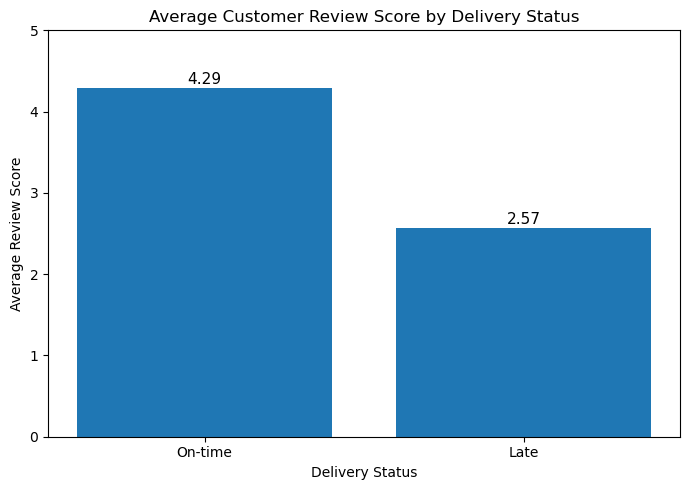

In [41]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    review_summary["delivery_status"],
    review_summary["review_score"]
)

plt.ylabel("Average Review Score")
plt.xlabel("Delivery Status")
plt.title("Average Customer Review Score by Delivery Status")
plt.ylim(0, 5)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [42]:
from pathlib import Path

print("Current notebook folder:")
print(Path.cwd())

print("\nPrediction file exists:")
print(Path("ml_predictions.csv").exists())

print("\nPrediction file:")
print(Path("ml_predictions.csv").resolve())

Current notebook folder:
/Users/devanshukumar/Desktop/eCommerce-Sales-Data-Analysis/ml

Prediction file exists:
True

Prediction file:
/Users/devanshukumar/Desktop/eCommerce-Sales-Data-Analysis/ml/ml_predictions.csv


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression metrics
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest metrics at our selected threshold
rf_pred = (rf_prob >= 0.30).astype(int)

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "Precision_Late": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall_Late": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1_Late": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(model_comparison.round(3))

                 Model  Accuracy  ROC_AUC  Precision_Late  Recall_Late  \
0  Logistic Regression     0.646    0.647           0.122        0.545   
1        Random Forest     0.844    0.736           0.238        0.419   

   F1_Late  
0    0.200  
1    0.304  


In [44]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [45]:
route_analysis = (
    delivered_orders
    .groupby(["customer_state", "seller_state"])
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("late_delivery", "sum")
    )
    .reset_index()
)

route_analysis["late_rate"] = (
    route_analysis["late_orders"] /
    route_analysis["total_orders"]
)

# Focus on routes with enough orders to be meaningful
route_analysis_filtered = route_analysis[
    route_analysis["total_orders"] >= 100
].copy()

route_analysis_filtered = route_analysis_filtered.sort_values(
    "late_rate",
    ascending=False
)

print(route_analysis_filtered.head(15).round(3))

    customer_state seller_state  total_orders  late_orders  late_rate
25              AL           SP           255           67      0.263
381             SP           MA           123           31      0.252
147             MA           SP           491          104      0.212
258             PI           SP           329           60      0.182
57              BA           PR           143           24      0.168
375             SE           SP           208           34      0.163
297             RJ           SP          8158         1264      0.155
80              CE           SP           969          148      0.153
63              BA           SP          2307          345      0.150
180             MS           SP           477           70      0.147
114             ES           SP          1461          207      0.142
290             RJ           PR           963          135      0.140
213             PA           SP           681           90      0.132
408             TO  

In [46]:
route_analysis_filtered.to_csv(
    "route_analysis.csv",
    index=False
)

print("Route analysis saved successfully!")

Route analysis saved successfully!
